# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

The dataset represents 17 marketing campaigns conducted between May 2008 and November 2010.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
##########################################
# Imports
##########################################

import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import precision_recall_curve
from sklearn.dummy import DummyClassifier



In [2]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [4]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [5]:
df.eq("unknown").sum()

age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

The objective is to predict whether a client will subscribe to a term deposit based on customer and campaign information.

This can help optimize marketing efforts by targeting customers with a higher likelihood of conversion.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

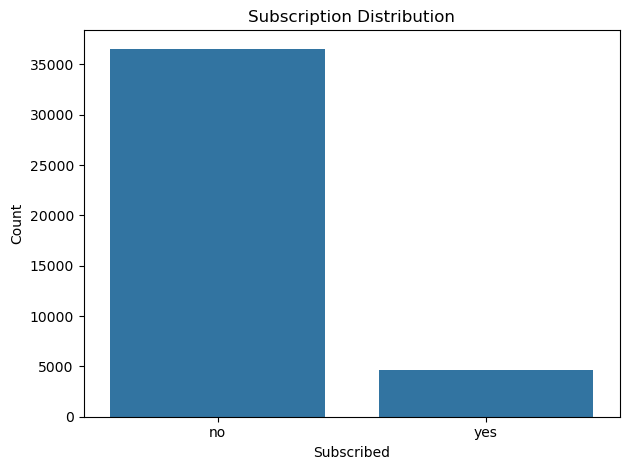

In [7]:
##########################################
# Plot: Subscription Distribution
##########################################


sns.countplot(data = df, x = "y")


plt.title("Subscription Distribution")
plt.xlabel("Subscribed")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


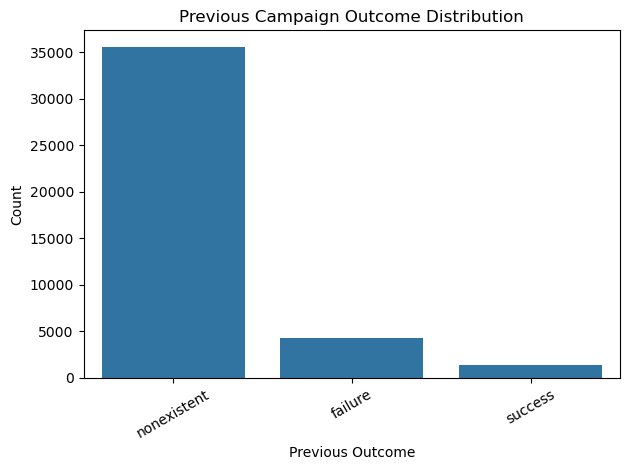

In [8]:
##########################################
# Plot: Previous Campaign Outcome Distribution
##########################################

sns.countplot(data = df, x = "poutcome")


plt.title("Previous Campaign Outcome Distribution")
plt.xlabel("Previous Outcome")
plt.ylabel("Count")


plt.xticks(rotation = 30)

plt.tight_layout()
plt.show()




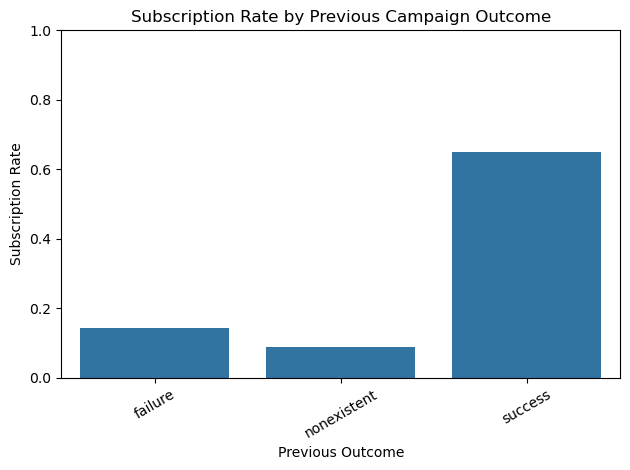

In [9]:
##########################################
# Plot: Subscription Rate by Previous Campaign Outcome
##########################################



poutcome_rate = (
    df.assign(subscribed = (df["y"] == "yes"))
    .groupby("poutcome")["subscribed"]
    .mean()
    .reset_index(name = "subscription_rate")
)


sns.barplot(
    data = poutcome_rate,
    x = "poutcome",
    y = "subscription_rate"
)



plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Previous Outcome")
plt.ylabel("Subscription Rate")

plt.ylim(0, 1)


plt.xticks(rotation = 30)


plt.tight_layout()
plt.show()




### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [10]:
##########################################
# Feature Engineering
##########################################

df = df.drop(columns = ["duration"])

X = df.drop("y", axis = 1)

y = (df["y"] == "yes").astype(int)




##########################################
# Feature Identification
##########################################

numeric_cols = X.select_dtypes(include = ["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include = ["object"]).columns


##########################################
# Preprocessing Pipeline
##########################################

preprocessor = (
    ColumnTransformer(
        [
            (
                "numeric", 
                StandardScaler(), 
                numeric_cols
            ),
            
            (
                "categorical", 
                OneHotEncoder(
                    drop = "if_binary", 
                    handle_unknown = "ignore"
                ), 
                categorical_cols
            )
        ]
    )
)






### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [11]:
##########################################
# Train/Test Split
##########################################

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size = 0.2, 
    random_state = 42, 
    stratify = y
)



##########################################
# Cross Validation Strategy
##########################################

cv = StratifiedKFold(
    n_splits = 5, 
    shuffle = True, 
    random_state = 42
)



### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [12]:
##########################################
# Baseline Model (Dummy Classifier)
##########################################


baseline_model = DummyClassifier(strategy = "most_frequent")


baseline_pipeline = (
    Pipeline(
        [
            ("preprocess", preprocessor),
            ("model", baseline_model)
        ]
    )
)

baseline_pipeline.fit(X_train, y_train)

baseline_accuracy = baseline_pipeline.score(X_test, y_test)

baseline_accuracy



0.8873512988589464

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [13]:
##########################################
# Simple Logistic Regression (Fit)
##########################################


log_model_simple = LogisticRegression(max_iter = 1000)

log_pipeline_simple = (
    Pipeline(
        [
            ("preprocess", preprocessor),
            ("model", log_model_simple)
        ]
    )
)

log_pipeline_simple.fit(X_train, y_train)



Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')),
                                                 ('categorical',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

### Problem 9: Score the Model

What is the accuracy of your model?

In [14]:
##########################################
# Simple Logistic Regression (Accuracy)
##########################################

log_accuracy_simple = log_pipeline_simple.score(X_test, y_test)

log_accuracy_simple

0.900825443068706

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [15]:
##########################################
##########################################
#
#           BASELINE (DUMMY) AND
#        DEFAULT MODEL COMPARISON
#               CALCULATION
#
##########################################
##########################################


models_baseline = {

    "Dummy (Baseline)" : DummyClassifier(strategy = "most_frequent"),
    "Logistic Regression" : LogisticRegression(max_iter = 1000),
    "Decision Tree" : DecisionTreeClassifier(random_state = 42),
    "KNN" : KNeighborsClassifier(),
    "SVM" : SVC()

}


baseline_rows = []

##########################################
# Model Training Loop
##########################################

for name, model in models_baseline.items():


    pipeline = (
        Pipeline(
            [
                ("preprocess", preprocessor),
                ("model", model)
            ]
        )
    )


    cv_scores = (
        cross_val_score(
            pipeline,
            X_train,
            y_train,
            cv = cv,
            scoring = "accuracy"
        )
    )


    start = time.time()

    pipeline.fit(X_train, y_train)

    train_time = time.time() - start


    train_accuracy = pipeline.score(X_train, y_train)

    test_accuracy = pipeline.score(X_test, y_test)


    baseline_rows.append(
        {
            "Model" : name,
            "Train Time" : train_time,
            "Train Accuracy" : train_accuracy,
            "CV Accuracy" : cv_scores.mean(),
            "CV Std" : cv_scores.std(),
            "Test Accuracy" : test_accuracy
        }
    )



##########################################
# Save Results
##########################################


df_baseline = pd.DataFrame(baseline_rows)

df_baseline.to_csv("baseline.csv", index = False)




    

In [16]:
##########################################
##########################################
#
#           BASELINE (DUMMY) AND
#        DEFAULT MODEL COMPARISON
#               RESULTS
#
##########################################
##########################################


##########################################
# Load Results
##########################################

df_baseline = pd.read_csv("baseline.csv")


##########################################
# Display Results
##########################################


display(
    df_baseline
    .set_index("Model")
    [
        [
            "Train Time",
            "Train Accuracy",
            "CV Accuracy",
            "CV Std",
            "Test Accuracy"
        ]
    ]
)



,Train Time,Train Accuracy,CV Accuracy,CV Std,Test Accuracy
Model,,,,,
Dummy (Baseline),0.053794,0.887344,0.887344,0.000074,0.887351
Logistic Regression,0.396070,0.899909,0.899575,0.002179,0.900825
Decision Tree,0.215702,0.995417,0.838422,0.005668,0.839160
KNN,0.057215,0.912200,0.889165,0.002756,0.896091
SVM,69.734196,0.904856,0.899727,0.001540,0.903496


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

## LOGISTIC REGRESSION

### C Sweep

In [17]:
##########################################
##########################################
#
#             LOGISTIC REGRESSION
#
#                  C SWEEP 
#                CALCULATION
#
##########################################
##########################################

##########################################
# Hyperparameters
##########################################

c_values = [0.001, 0.01, 0.1, 1]


log_c_rows = []


##########################################
# Model Training Loop
##########################################

for c_value in c_values:

    pipeline = (
        Pipeline(
            [
                ("preprocess", preprocessor),
                ("model", LogisticRegression(
                    C = c_value, 
                    max_iter = 1000
                ))
            ]
        )
    )


    cv_scores = (
        cross_val_score(
            pipeline,
            X_train,
            y_train,
            cv = cv,
            scoring = "accuracy"
        )
    )

    pipeline.fit(X_train, y_train)


    train_accuracy = pipeline.score(X_train, y_train)

    test_accuracy = pipeline.score(X_test, y_test)


    log_c_rows.append(
        {
            "C" : c_value,
            "Train Accuracy" : train_accuracy,
            "CV Accuracy" : cv_scores.mean(),
            "CV Std" : cv_scores.std(),
            "Test Accuracy" : test_accuracy
        }
    )



##########################################
# Save Results
##########################################

df_log_c = pd.DataFrame(log_c_rows)

df_log_c.to_csv("log_c.csv", index = False)




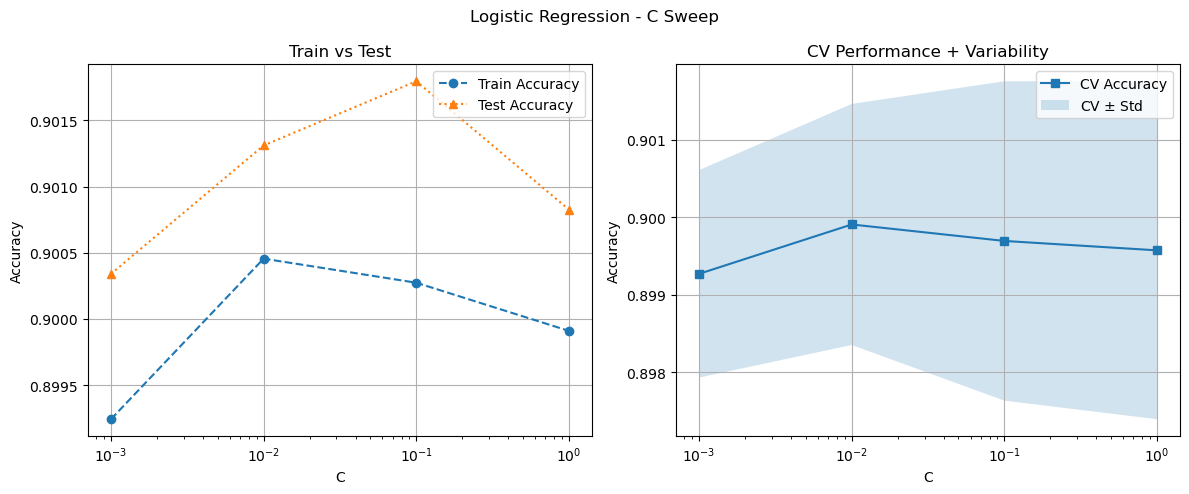

,Train Accuracy,CV Accuracy,CV Std,Test Accuracy
C,,,,
0.001,0.899241,0.899272,0.001338,0.900340
0.010,0.900455,0.899909,0.001555,0.901311
0.100,0.900273,0.899697,0.002061,0.901797
1.000,0.899909,0.899575,0.002179,0.900825


In [18]:
##########################################
##########################################
#
#             LOGISTIC REGRESSION
#
#                  C SWEEP 
#                    PLOT
#
##########################################
##########################################


##########################################
# Load Results
##########################################

df_log_c = pd.read_csv("log_c.csv").sort_values("C")


fig, axes = plt.subplots(1, 2, figsize = (12, 5))


##########################################
# Plot: Train vs Test
##########################################


axes[0].semilogx(
    df_log_c["C"],
    df_log_c["Train Accuracy"],
    linestyle = "--",
    marker = "o",
    label = "Train Accuracy"
)


axes[0].semilogx(
    df_log_c["C"],
    df_log_c["Test Accuracy"],
    linestyle = ":",
    marker = "^",
    label = "Test Accuracy"
)


axes[0].set_title("Train vs Test")
axes[0].set_xlabel("C")
axes[0].set_ylabel("Accuracy")

axes[0].set_xticks(df_log_c["C"])

axes[0].legend(loc = "upper right")
axes[0].grid(True)


##########################################
# Plot: CV Performance
##########################################


axes[1].semilogx(
    df_log_c["C"],
    df_log_c["CV Accuracy"],
    linestyle = "-",
    marker = "s",
    label = "CV Accuracy"
)


axes[1].fill_between(
    df_log_c["C"],
    df_log_c["CV Accuracy"] - df_log_c["CV Std"],
    df_log_c["CV Accuracy"] + df_log_c["CV Std"],
    alpha = 0.2,
    label = "CV $\pm$ Std"
)


axes[1].set_title("CV Performance + Variability")
axes[1].set_xlabel("C")
axes[1].set_ylabel("Accuracy")

axes[1].set_xticks(df_log_c["C"])

axes[1].legend(loc = "upper right")
axes[1].grid(True)



##########################################
# Final Plot Formatting
##########################################

fig.suptitle("Logistic Regression - C Sweep")


plt.tight_layout()
plt.show()


##########################################
# Display Results
##########################################

display(
    df_log_c
    .set_index("C")
    [
        [
            "Train Accuracy",
            "CV Accuracy",
            "CV Std",
            "Test Accuracy"
        ]
    ]
)





### C Sweep Insights

The C sweep explores the effect of regularization strength on Logistic Regression performance.

As C increases, training accuracy improves while test accuracy stabilizes, indicating reduced regularization allows the model to better fit the training data without significantly improving generalization. 

Overall, moderate values of C provide a strong balance between bias and variance. 

### Degree Sweep

In [19]:
##########################################
##########################################
#
#             LOGISTIC REGRESSION
#
#               DEGREE SWEEP
#               CALCULATION
#
##########################################
##########################################


##########################################
# Hyperparameters
##########################################

degree_values = [1, 2, 3]

c_fixed = 1

log_poly_rows = []


##########################################
# Model Training Loop
##########################################

for degree_value in degree_values:

    numeric_pipeline = (
        Pipeline(
            [
                ("poly", 
                 PolynomialFeatures(
                    degree = degree_value, 
                    include_bias = False
                 )),
                ("scaler", StandardScaler())
            ]
        )
    )


    preprocessor_poly = (
        ColumnTransformer(
            [
                ("numeric", numeric_pipeline, numeric_cols),
                ("categorical", OneHotEncoder(
                    drop = "if_binary", 
                    handle_unknown = "ignore"
                ), categorical_cols)
            ]
        )
    )
            

    pipeline = (
        Pipeline(
            [
                ("preprocess", preprocessor_poly),
                ("model", LogisticRegression(
                    C = c_fixed, 
                    max_iter = 1000
                ))
            ]
        )
    )

    

    cv_scores = (
        cross_val_score(
            pipeline,
            X_train,
            y_train,
            cv = cv,
            scoring = "accuracy"
        )
    )

    pipeline.fit(X_train, y_train)


    train_accuracy = pipeline.score(X_train, y_train)

    test_accuracy = pipeline.score(X_test, y_test)


    log_poly_rows.append(
        {
            "Degree" : degree_value,
            "Train Accuracy" : train_accuracy,
            "CV Accuracy" : cv_scores.mean(),
            "CV Std" : cv_scores.std(),
            "Test Accuracy" : test_accuracy
        }
    )



##########################################
# Save Results
##########################################

df_log_poly = pd.DataFrame(log_poly_rows)


df_log_poly.to_csv("log_poly.csv", index = False)



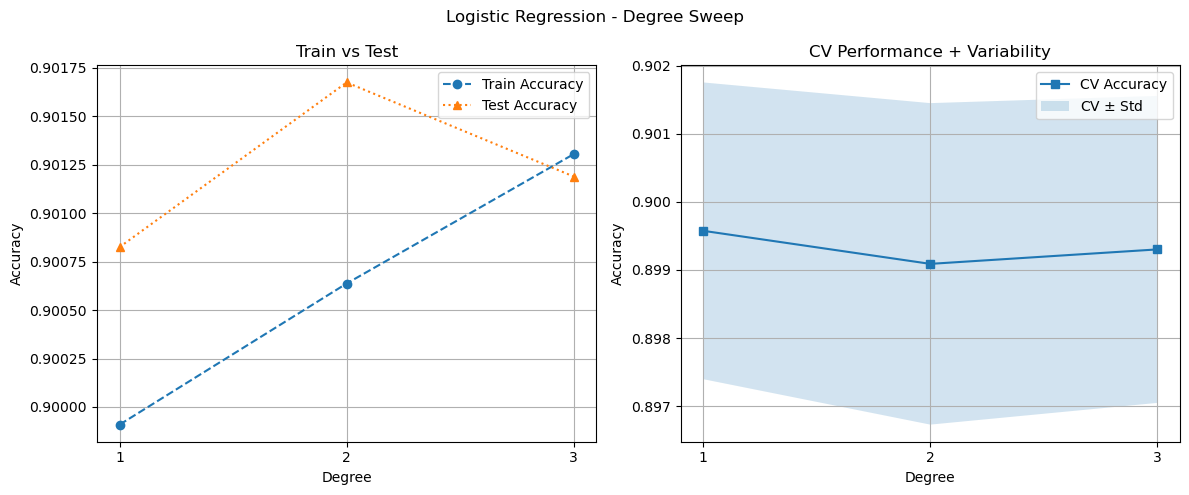

,Train Accuracy,CV Accuracy,CV Std,Test Accuracy
Degree,,,,
1,0.899909,0.899575,0.002179,0.900825
2,0.900637,0.899090,0.002361,0.901675
3,0.901305,0.899302,0.002254,0.901190


In [20]:
##########################################
##########################################
#
#             LOGISTIC REGRESSION
#
#               DEGREE SWEEP
#                   PLOT
#
##########################################
##########################################


##########################################
# Load Results
##########################################


df_log_poly = pd.read_csv("log_poly.csv").sort_values("Degree")


fig, axes = plt.subplots(1, 2, figsize = (12, 5))



##########################################
# Plot: Train vs Test
##########################################

axes[0].plot(
    df_log_poly["Degree"],
    df_log_poly["Train Accuracy"],
    linestyle = "--",
    marker = "o",
    label = "Train Accuracy"
)


axes[0].plot(
    df_log_poly["Degree"],
    df_log_poly["Test Accuracy"],
    linestyle = ":",
    marker = "^",
    label = "Test Accuracy"
)


axes[0].set_title("Train vs Test")
axes[0].set_xlabel("Degree")
axes[0].set_ylabel("Accuracy")


axes[0].set_xticks(df_log_poly["Degree"])


axes[0].legend(loc = "upper right")
axes[0].grid(True)


##########################################
# Plot: CV Performance
##########################################


axes[1].plot(
    df_log_poly["Degree"],
    df_log_poly["CV Accuracy"],
    linestyle = "-",
    marker = "s",
    label = "CV Accuracy"
)


axes[1].fill_between(
    df_log_poly["Degree"],
    df_log_poly["CV Accuracy"] - df_log_poly["CV Std"],
    df_log_poly["CV Accuracy"] + df_log_poly["CV Std"],
    alpha = 0.2,
    label = "CV $\pm$ Std"
)


axes[1].set_title("CV Performance + Variability")
axes[1].set_xlabel("Degree")
axes[1].set_ylabel("Accuracy")

axes[1].set_xticks(df_log_poly["Degree"])

axes[1].legend(loc = "upper right")
axes[1].grid(True)


##########################################
# Final Plot Formatting
##########################################

fig.suptitle("Logistic Regression - Degree Sweep")


plt.tight_layout()
plt.show()

##########################################
# Display Results
##########################################


display(
    df_log_poly
    .set_index("Degree")
    [
        [
            "Train Accuracy",
            "CV Accuracy",
            "CV Std",
            "Test Accuracy"
        ]
    ]
)
    

### Degree Sweep Insights

The polynomial degree sweep evaluates whether increasing feature complexity improves model performance.

Higher-degree features slightly improve training accuracy but introduce greater variability, with limited gains in test accuracy.

This suggests that additional feature complexity provides diminishing returns for this dataset. 

### Heatmap

In [21]:
##########################################
##########################################
#
#             LOGISTIC REGRESSION
#
#           HYPERPARAMETER HEATMAP
#                CALCULATION
#
##########################################
##########################################



##########################################
# Hyperparameters
##########################################

degree_values = [1, 2, 3]

c_values = [0.001, 0.01, 0.1, 1]


log_heat_rows = []


##########################################
# Model Training Loop
##########################################

for degree_value in degree_values:
    for c_value in c_values:

        numeric_pipeline = (
            Pipeline(
                [
                    ("poly", PolynomialFeatures(
                        degree = degree_value, 
                        include_bias = False
                    )),
                    ("scaler", StandardScaler())
                ]
            )
        )
    
    
        preprocessor_poly = (
            ColumnTransformer(
                [
                    ("numeric", numeric_pipeline, numeric_cols),
                    ("categorical", OneHotEncoder(
                        drop = "if_binary", 
                        handle_unknown = "ignore"
                    ), categorical_cols)
                ]
            )
        )
                           
    
        pipeline = (
            Pipeline(
                [
                    ("preprocess", preprocessor_poly),
                    ("model", LogisticRegression(
                        C = c_value, 
                        max_iter = 1000
                    ))
                ]
            )
        )
           
    
        cv_scores = (
            cross_val_score(
                pipeline,
                X_train,
                y_train,
                cv = cv,
                scoring = "accuracy"
            )
        )
    
        pipeline.fit(X_train, y_train)
    
    
        train_accuracy = pipeline.score(X_train, y_train)
    
        test_accuracy = pipeline.score(X_test, y_test)
    
    
        log_heat_rows.append(
            {
                "Degree" : degree_value,
                "C" : c_value,
                "Train Accuracy" : train_accuracy,
                "CV Accuracy" : cv_scores.mean(),
                "CV Std" : cv_scores.std(),
                "Test Accuracy" : test_accuracy
            }
        )


##########################################
# Save Results
##########################################

df_log_heat = pd.DataFrame(log_heat_rows)


df_log_heat.to_csv("log_heat.csv", index = False)




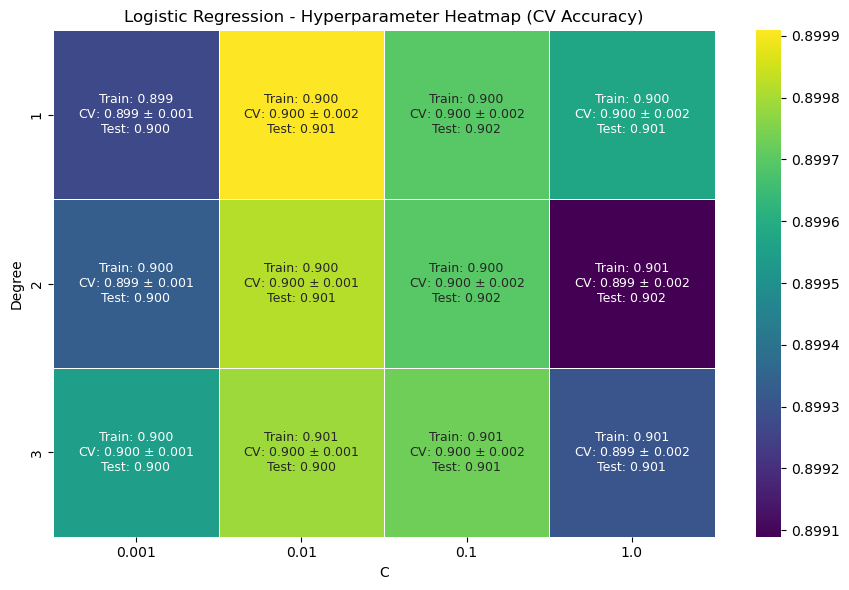

In [22]:
##########################################
##########################################
#
#             LOGISTIC REGRESSION
#
#           HYPERPARAMETER HEATMAP
#                    PLOT
#
##########################################
##########################################


##########################################
# Load Results
##########################################

df_log_heat = pd.read_csv("log_heat.csv")



##########################################
# Create Annotations
##########################################


df_log_heat["label"] = df_log_heat.apply(
    lambda row: (
        f"Train: {row['Train Accuracy']:.3f}\n"
        f"CV: {row['CV Accuracy']:.3f} $\pm$ {row['CV Std']:.3f}\n"
        f"Test: {row['Test Accuracy']:.3f}"
    ), 
    axis = 1
)

##########################################
# Pivot Tables
##########################################


degree_order = sorted(df_log_heat["Degree"].unique())

c_order = sorted(df_log_heat["C"].unique())


log_mean_table = df_log_heat.pivot(
    index = "Degree",
    columns = "C",
    values = "CV Accuracy"
).reindex(index = degree_order, columns = c_order)



log_label_table = df_log_heat.pivot(
    index = "Degree",
    columns = "C", 
    values = "label"
).reindex(index = degree_order, columns = c_order)


##########################################
# Plot: Heatmap
##########################################


plt.figure(figsize = (9, 6))

sns.heatmap(
    log_mean_table,
    annot = log_label_table,
    fmt = "",
    cmap = "viridis",
    linewidths = 0.5,
    linecolor = "white",
    annot_kws = {"fontsize" : 9}
)

plt.title("Logistic Regression - Hyperparameter Heatmap (CV Accuracy)")
plt.xlabel("C")
plt.ylabel("Degree")

plt.tight_layout()
plt.show()






### Heatmap Insights

The heatmap illustrates the interaction between polynomial degree and regularization strength.

Results show that moderate regularization with low-degree features provides the most stable performance, while higher-degree configurations increase variance without meaningful improvement.

This reinforces that simpler models tend to provide more reliable performance.

### Logistic Regression Summary

Logistic Regression provides stable and consistent performance across configurations.

While tuning improves training performance, gains on test accuracy are modest, suggesting limited separability in the dataset using linear decision boundaries alone. 

The final selected model uses C = 0.1 with no polynomial feature expansion (degree = 1).

## Decision Tree

### Max Depth Sweep

In [23]:
##########################################
##########################################
#
#              DECISION TREE
#
#             MAX DEPTH SWEEP
#               CALCULATION
#
##########################################
##########################################


##########################################
# Hyperparameters
##########################################

max_depth_values = [3, 5, 7, 10]

tree_depth_rows = []


##########################################
# Model Training Loop
##########################################

for max_depth_value in max_depth_values:

    pipeline = (
        Pipeline(
            [
                ("preprocess", preprocessor),
                ("model", DecisionTreeClassifier(
                    max_depth = max_depth_value, 
                    min_samples_leaf = 1,
                    random_state = 42
                ))
            ]
        )
    )
   
    cv_scores = (
        cross_val_score(
            pipeline,
            X_train,
            y_train,
            cv = cv,
            scoring = "accuracy"
        )
    )

    pipeline.fit(X_train, y_train)


    train_accuracy = pipeline.score(X_train, y_train)

    test_accuracy = pipeline.score(X_test, y_test)


    tree_depth_rows.append(
        {
            "Max Depth" : max_depth_value,
            "Train Accuracy" : train_accuracy,
            "CV Accuracy" : cv_scores.mean(),
            "CV Std" : cv_scores.std(),
            "Test Accuracy" : test_accuracy
        }
    )


##########################################
# Save Results
##########################################

df_tree_depth = pd.DataFrame(tree_depth_rows)


df_tree_depth.to_csv("tree_depth.csv", index = False)



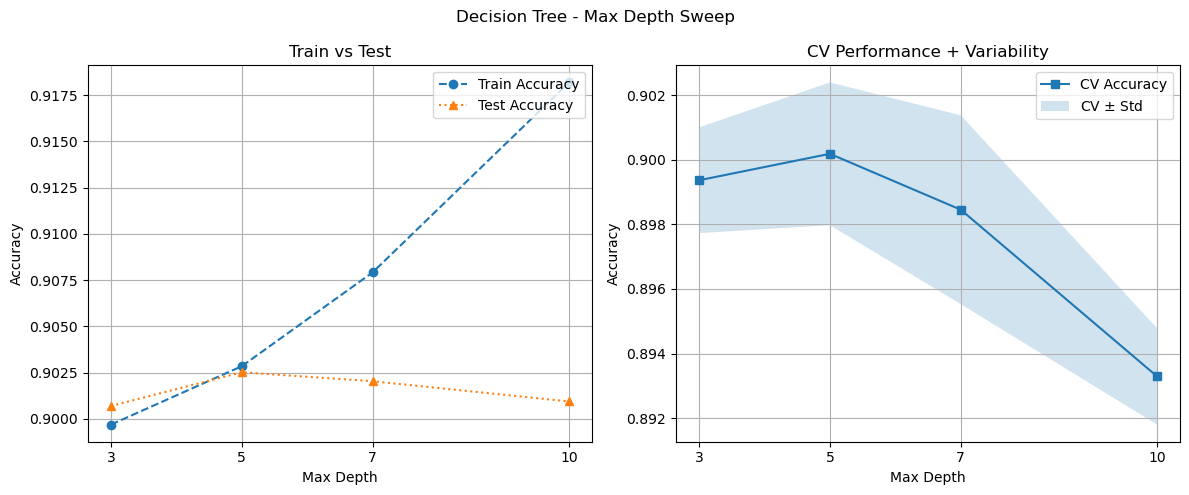

,Train Accuracy,CV Accuracy,CV Std,Test Accuracy
Max Depth,,,,
3,0.899697,0.899363,0.001635,0.900704
5,0.902853,0.900182,0.002208,0.902525
7,0.907921,0.898452,0.002923,0.902039
10,0.918179,0.893293,0.001491,0.900947


In [24]:
##########################################
##########################################
#
#              DECISION TREE
#
#             MAX DEPTH SWEEP
#                  PLOT
#
##########################################
##########################################


##########################################
# Load Results
##########################################

df_tree_depth = pd.read_csv("tree_depth.csv").sort_values("Max Depth")


fig, axes = plt.subplots(1, 2, figsize = (12, 5))


##########################################
# Plot: Train vs Test
##########################################

axes[0].plot(
    df_tree_depth["Max Depth"],
    df_tree_depth["Train Accuracy"],
    linestyle = "--",
    marker = "o",
    label = "Train Accuracy"
)


axes[0].plot(
    df_tree_depth["Max Depth"],
    df_tree_depth["Test Accuracy"],
    linestyle = ":",
    marker = "^",
    label = "Test Accuracy"
)


axes[0].set_title("Train vs Test")
axes[0].set_xlabel("Max Depth")
axes[0].set_ylabel("Accuracy")


axes[0].set_xticks(df_tree_depth["Max Depth"])


axes[0].legend(loc = "upper right")
axes[0].grid(True)



##########################################
# Plot: CV Performance
##########################################


axes[1].plot(
    df_tree_depth["Max Depth"],
    df_tree_depth["CV Accuracy"],
    linestyle = "-",
    marker = "s",
    label = "CV Accuracy"
)


axes[1].fill_between(
    df_tree_depth["Max Depth"],
    df_tree_depth["CV Accuracy"] - df_tree_depth["CV Std"],
    df_tree_depth["CV Accuracy"] + df_tree_depth["CV Std"],
    alpha = 0.2,
    label = "CV $\pm$ Std"
)


axes[1].set_title("CV Performance + Variability")
axes[1].set_xlabel("Max Depth")
axes[1].set_ylabel("Accuracy")


axes[1].set_xticks(df_tree_depth["Max Depth"])

axes[1].legend(loc = "upper right")
axes[1].grid(True)



##########################################
# Final Plot Formatting
##########################################


fig.suptitle("Decision Tree - Max Depth Sweep")


plt.tight_layout()
plt.show()


##########################################
# Display Results
##########################################


display(
    df_tree_depth
    .set_index("Max Depth")
    [
        [
            "Train Accuracy",
            "CV Accuracy",
            "CV Std",
            "Test Accuracy"
        ]
    ]
)
    




### Max Depth Sweep Insights

The max depth sweep evaluates how tree complexity impacts model performance. 

As depth increases, training accuracy improves significantly, while test accuracy plateaus, indicating overfitting at higher depths.

Shallower trees provide a better balance between flexibility and generalization.

### Min Samples Leaf Sweep

In [25]:
##########################################
##########################################
#
#              DECISION TREE
#
#          MIN SAMPLES LEAF SWEEP
#               CALCULATION
#
##########################################
##########################################


##########################################
# Hyperparameters
##########################################

min_samples_leaf_values = [1, 5, 10, 20]

tree_min_leaf_rows = []


##########################################
# Model Training Loop
##########################################

for min_samples_leaf_value in min_samples_leaf_values:

    pipeline = (
        Pipeline(
            [
                ("preprocess", preprocessor),
                ("model", DecisionTreeClassifier(
                    max_depth = 5,
                    min_samples_leaf = min_samples_leaf_value, 
                    random_state = 42
                ))
            ]
        )
    )

    cv_scores = (
        cross_val_score(
            pipeline,
            X_train,
            y_train,
            cv = cv,
            scoring = "accuracy"
        )
    )

    pipeline.fit(X_train, y_train)


    train_accuracy = pipeline.score(X_train, y_train)

    test_accuracy = pipeline.score(X_test, y_test)


    tree_min_leaf_rows.append(
        {
            "Min Samples Leaf" : min_samples_leaf_value,
            "Train Accuracy" : train_accuracy,
            "CV Accuracy" : cv_scores.mean(),
            "CV Std" : cv_scores.std(),
            "Test Accuracy" : test_accuracy
        }
    )


##########################################
# Save Results
##########################################

df_tree_min_leaf = pd.DataFrame(tree_min_leaf_rows)


df_tree_min_leaf.to_csv("tree_min_leaf.csv", index = False)



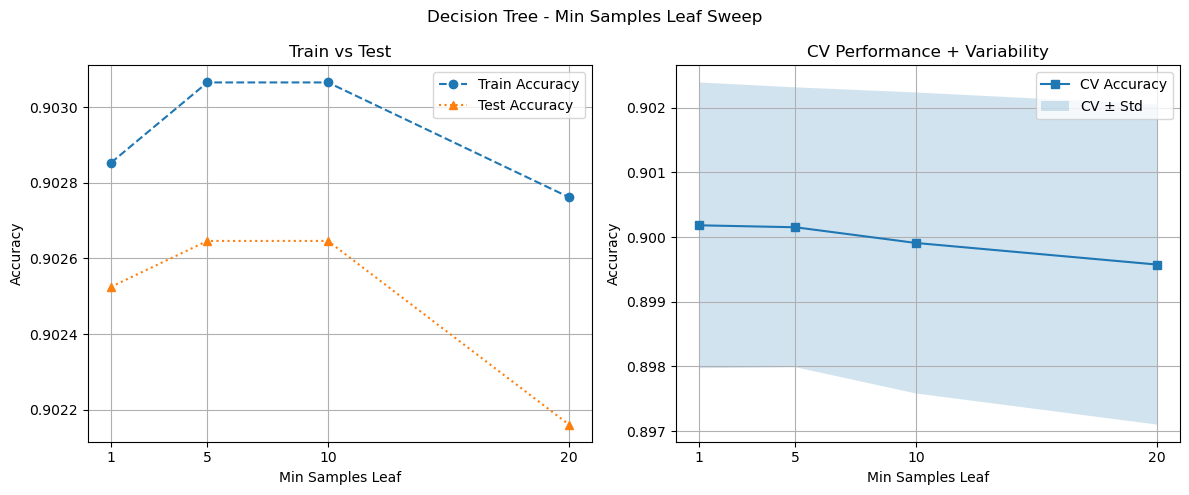

,Train Accuracy,CV Accuracy,CV Std,Test Accuracy
Min Samples Leaf,,,,
1,0.902853,0.900182,0.002208,0.902525
5,0.903065,0.900152,0.002163,0.902646
10,0.903065,0.899909,0.002326,0.902646
20,0.902762,0.899575,0.002474,0.902161


In [26]:
##########################################
##########################################
#
#              DECISION TREE
#
#          MIN SAMPLES LEAF SWEEP
#                   PLOT
#
##########################################
##########################################

##########################################
# Load Results
##########################################

df_tree_min_leaf = pd.read_csv("tree_min_leaf.csv").sort_values("Min Samples Leaf")


fig, axes = plt.subplots(1, 2, figsize = (12, 5))


##########################################
# Plot: Train vs Test
##########################################


axes[0].plot(
    df_tree_min_leaf["Min Samples Leaf"],
    df_tree_min_leaf["Train Accuracy"],
    linestyle = "--",
    marker = "o",
    label = "Train Accuracy"
)


axes[0].plot(
    df_tree_min_leaf["Min Samples Leaf"],
    df_tree_min_leaf["Test Accuracy"],
    linestyle = ":",
    marker = "^",
    label = "Test Accuracy"
)


axes[0].set_title("Train vs Test")
axes[0].set_xlabel("Min Samples Leaf")
axes[0].set_ylabel("Accuracy")

axes[0].set_xticks(df_tree_min_leaf["Min Samples Leaf"])

axes[0].legend(loc = "upper right")
axes[0].grid(True)



##########################################
# Plot: CV Performance
##########################################


axes[1].plot(
    df_tree_min_leaf["Min Samples Leaf"],
    df_tree_min_leaf["CV Accuracy"],
    linestyle = "-",
    marker = "s",
    label = "CV Accuracy"
)


axes[1].fill_between(
    df_tree_min_leaf["Min Samples Leaf"],
    df_tree_min_leaf["CV Accuracy"] - df_tree_min_leaf["CV Std"],
    df_tree_min_leaf["CV Accuracy"] + df_tree_min_leaf["CV Std"],
    alpha = 0.2,
    label = "CV $\pm$ Std"
)



axes[1].set_title("CV Performance + Variability")
axes[1].set_xlabel("Min Samples Leaf")
axes[1].set_ylabel("Accuracy")

axes[1].set_xticks(df_tree_min_leaf["Min Samples Leaf"])


axes[1].legend(loc = "upper right")
axes[1].grid(True)



##########################################
# Final Plot Formatting
##########################################

fig.suptitle("Decision Tree - Min Samples Leaf Sweep")


plt.tight_layout()
plt.show()


##########################################
# Display Results
##########################################


display(
    df_tree_min_leaf
    .set_index("Min Samples Leaf")
    [
        [
            "Train Accuracy",
            "CV Accuracy",
            "CV Std",
            "Test Accuracy"
        ]
    ]
)
    



### Min Samples Leaf Insights

The minimum samples per leaf parameter controls how granular the tree splits are.

Increasing this value reduces overfitting by limiting overly specific splits, resulting in more stable test performance.

Moderate values provide the best trade-off between model flexibility and robustness.

### Heatmap

In [27]:
##########################################
##########################################
#
#              DECISION TREE
#
#           HYPERPARAMETER HEATMAP
#                CALCULATION
#
##########################################
##########################################


##########################################
# Hyperparameters
##########################################

max_depth_values = [3, 5, 7, 10]

min_samples_leaf_values = [1, 5, 10, 20]


tree_heat_rows = []


##########################################
# Model Training Loop
##########################################


for max_depth_value in max_depth_values:
    for min_samples_leaf_value in min_samples_leaf_values:


        pipeline = (
            Pipeline(
                [
                    ("preprocess", preprocessor),
                    ("model", DecisionTreeClassifier(
                        max_depth = max_depth_value, 
                        min_samples_leaf = min_samples_leaf_value, 
                        random_state = 42
                    ))
                ]
            )
        )


        cv_scores = (
            cross_val_score(
                pipeline,
                X_train,
                y_train,
                cv = cv,
                scoring = "accuracy"
            )
        )
    
        pipeline.fit(X_train, y_train)
    
    
        train_accuracy = pipeline.score(X_train, y_train)
    
        test_accuracy = pipeline.score(X_test, y_test)
    
    
        tree_heat_rows.append(
            {
                "Max Depth" : max_depth_value,
                "Min Samples Leaf" : min_samples_leaf_value,
                "Train Accuracy" : train_accuracy,
                "CV Accuracy" : cv_scores.mean(),
                "CV Std" : cv_scores.std(),
                "Test Accuracy" : test_accuracy
            }
        )



##########################################
# Save Results
##########################################

df_tree_heat = pd.DataFrame(tree_heat_rows)


df_tree_heat.to_csv("tree_heat.csv", index = False)


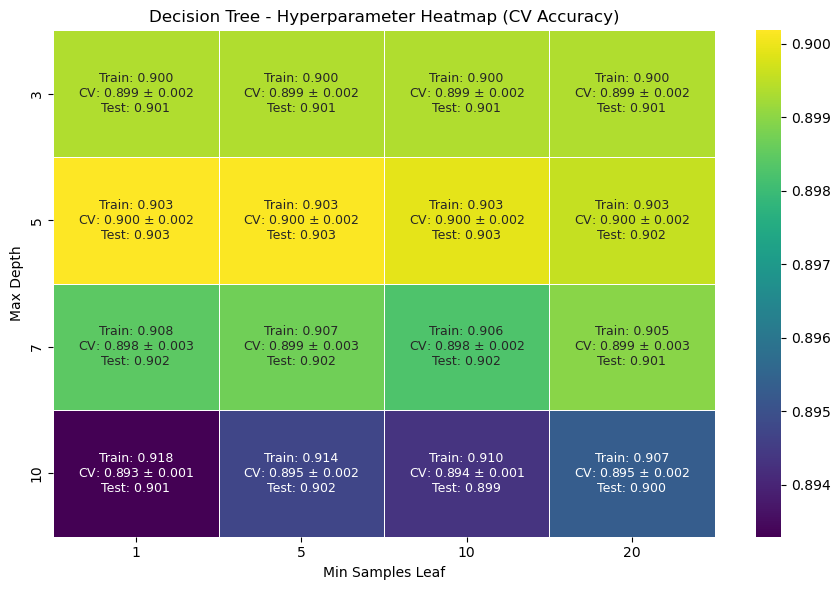

In [28]:
##########################################
##########################################
#
#              DECISION TREE
#
#           HYPERPARAMETER HEATMAP
#                   PLOT
#
##########################################
##########################################



##########################################
# Load Results
##########################################

df_tree_heat = pd.read_csv("tree_heat.csv")



##########################################
# Create Annotations
##########################################

df_tree_heat["label"] = df_tree_heat.apply(
    lambda row: (
        f"Train: {row['Train Accuracy']:.3f}\n"
        f"CV: {row['CV Accuracy']:.3f} $\pm$ {row['CV Std']:.3f}\n"
        f"Test: {row['Test Accuracy']:.3f}"
    ), 
    axis = 1
)


##########################################
# Pivot Tables
##########################################

depth_order = sorted(df_tree_heat["Max Depth"].unique())

leaf_order = sorted(df_tree_heat["Min Samples Leaf"].unique())


tree_mean_table = df_tree_heat.pivot(
    index = "Max Depth",
    columns = "Min Samples Leaf",
    values = "CV Accuracy"
).reindex(index = depth_order, columns = leaf_order)


tree_label_table = df_tree_heat.pivot(
    index = "Max Depth",
    columns = "Min Samples Leaf", 
    values = "label"
).reindex(index = depth_order, columns = leaf_order)



##########################################
# Plot: Heatmap
##########################################


plt.figure(figsize = (9, 6))

sns.heatmap(
    tree_mean_table,
    annot = tree_label_table,
    fmt = "",
    cmap = "viridis",
    linewidths = 0.5,
    linecolor = "white",
    annot_kws = {"fontsize" : 9}
)

plt.title("Decision Tree - Hyperparameter Heatmap (CV Accuracy)")
plt.xlabel("Min Samples Leaf")
plt.ylabel("Max Depth")

plt.tight_layout()
plt.show()




### Heatmap Insights

The heatmap shows the interaction between tree depth and minimum samples per leaf.

Results indicate that deeper trees require stronger regularization to avoid overfitting, while simpler trees perform consistently across settings. 

Overall, controlled complexity leads to more reliable performance. 

### Decision Tree Summary

Decision trees capture non-linear relationships but are highly sensitive to overfitting.

While tuning improves training performance, deeper trees lead to overfitting, requiring constraints to maintain generalization.

The final selected model uses max_depth = 5 and min_samples_leaf = 20.

## K NEAREST NEIGHBORS

### N Neighbors Sweep

In [29]:
##########################################
##########################################
#
#           K NEAREST NEIGHBORS
#
#            N NEIGHBORS SWEEP
#               CALCULATION
#
##########################################
##########################################


##########################################
# Hyperparameters
##########################################

n_neighbors_values = [1, 3, 5, 7, 9, 11, 15, 21]


knn_rows = []


##########################################
# Model Training Loop
##########################################

for n_neighbors_value in n_neighbors_values:


    pipeline = (
        Pipeline(
            [
                ("preprocess", preprocessor),
                ("model", KNeighborsClassifier(
                    n_neighbors = n_neighbors_value
                ))
            ]
        )
    )

    
    cv_scores = (
        cross_val_score(
            pipeline,
            X_train,
            y_train,
            cv = cv,
            scoring = "accuracy"
        )
    )

    pipeline.fit(X_train, y_train)


    train_accuracy = pipeline.score(X_train, y_train)

    test_accuracy = pipeline.score(X_test, y_test)


    knn_rows.append(
        {
            "N Neighbors" : n_neighbors_value,
            "Train Accuracy" : train_accuracy,
            "CV Accuracy" : cv_scores.mean(),
            "CV Std" : cv_scores.std(),
            "Test Accuracy" : test_accuracy
        }
    )


##########################################
# Save Results
##########################################

df_knn = pd.DataFrame(knn_rows)


df_knn.to_csv("knn.csv", index = False)



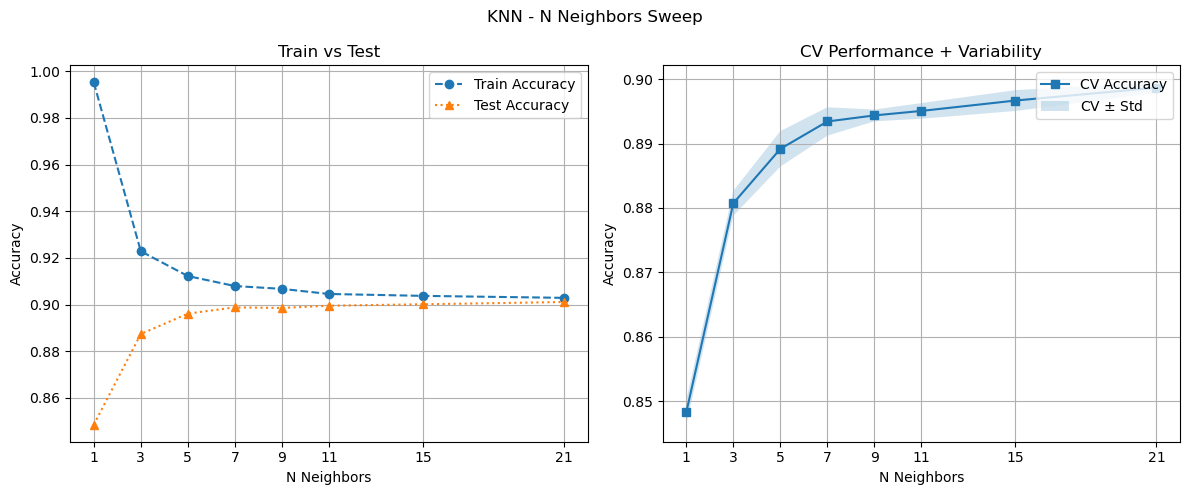

,Train Accuracy,CV Accuracy,CV Std,Test Accuracy
N Neighbors,,,,
1,0.995205,0.848316,0.001914,0.848507
3,0.922822,0.880728,0.001927,0.887351
5,0.912200,0.889165,0.002756,0.896091
7,0.907921,0.893414,0.002202,0.898762
9,0.906707,0.894355,0.000918,0.898519
11,0.904522,0.895053,0.001216,0.899490
15,0.903703,0.896662,0.001614,0.900097
21,0.902853,0.898665,0.000805,0.901068


In [30]:
##########################################
##########################################
#
#           K NEAREST NEIGHBORS
#
#            N NEIGHBORS SWEEP
#                  PLOT
#
##########################################
##########################################


##########################################
# Load Results
##########################################


df_knn = pd.read_csv("knn.csv").sort_values("N Neighbors")


fig, axes = plt.subplots(1, 2, figsize = (12, 5))


##########################################
# Plot: Train vs Test
##########################################

axes[0].plot(
    df_knn["N Neighbors"],
    df_knn["Train Accuracy"],
    linestyle = "--",
    marker = "o",
    label = "Train Accuracy"
)

axes[0].plot(
    df_knn["N Neighbors"],
    df_knn["Test Accuracy"],
    linestyle = ":",
    marker = "^",
    label = "Test Accuracy"
)


axes[0].set_title("Train vs Test")
axes[0].set_xlabel("N Neighbors")
axes[0].set_ylabel("Accuracy")


axes[0].set_xticks(df_knn["N Neighbors"])

axes[0].legend(loc = "upper right")
axes[0].grid(True)


##########################################
# Plot: CV Performance
##########################################


axes[1].plot(
    df_knn["N Neighbors"],
    df_knn["CV Accuracy"],
    linestyle = "-",
    marker = "s",
    label = "CV Accuracy"
)


axes[1].fill_between(
    df_knn["N Neighbors"],
    df_knn["CV Accuracy"] - df_knn["CV Std"],
    df_knn["CV Accuracy"] + df_knn["CV Std"],
    alpha = 0.2,
    label = "CV $\pm$ Std"
)


axes[1].set_title("CV Performance + Variability")
axes[1].set_xlabel("N Neighbors")
axes[1].set_ylabel("Accuracy")


axes[1].set_xticks(df_knn["N Neighbors"])

axes[1].legend(loc = "upper right")
axes[1].grid(True)



##########################################
# Final Plot Formatting
##########################################


fig.suptitle("KNN - N Neighbors Sweep")

plt.tight_layout()
plt.show()


##########################################
# Display Results
##########################################


display(
    df_knn
    .set_index("N Neighbors")
    [
        [
            "Train Accuracy",
            "CV Accuracy",
            "CV Std",
            "Test Accuracy"
        ]
    ]
)
    



### N Neighbors Sweep Insights

The number of neighbors controls the balance between model flexibility and stability.

Lower values lead to high variance and overfitting, while higher values smooth predictions and improve generalization.

Larger values provide the best performance by balancing bias and variance.

### K Nearest Neighbors Summary

KNN performance is sensitive to the choice of neighbors and relies heavily on proper feature scaling.

While simple, it provides competitive results without requiring complex tuning. 

The final selected model uses n_neighbors = 21.

## SUPPORT VECTOR MACHINES

### C Sweep

In [31]:
##########################################
##########################################
#
#         SUPPORT VECTOR MACHINES
#
#                C SWEEP
#               CALCULATION
#
##########################################
##########################################


##########################################
# Hyperparameters
##########################################

c_values = [0.1, 1, 10]

svm_c_rows = []


##########################################
# Model Training Loop
##########################################


for c_value in c_values:

    pipeline = (
        Pipeline(
            [
                ("preprocess", preprocessor),
                ("model", SVC(
                    C = c_value, 
                    kernel = "rbf",
                    gamma = "scale"
                ))
            ]
        )
    )

    cv_scores = (
        cross_val_score(
            pipeline,
            X_train,
            y_train,
            cv = cv,
            scoring = "accuracy"
        )
    )

    pipeline.fit(X_train, y_train)


    train_accuracy = pipeline.score(X_train, y_train)

    test_accuracy = pipeline.score(X_test, y_test)


    svm_c_rows.append(
        {
            "C" : c_value,
            "Train Accuracy" : train_accuracy,
            "CV Accuracy" : cv_scores.mean(),
            "CV Std" : cv_scores.std(),
            "Test Accuracy" : test_accuracy
        }
    )


##########################################
# Save Results
##########################################


df_svm_c = pd.DataFrame(svm_c_rows)

df_svm_c.to_csv("svm_c.csv", index = False)
    




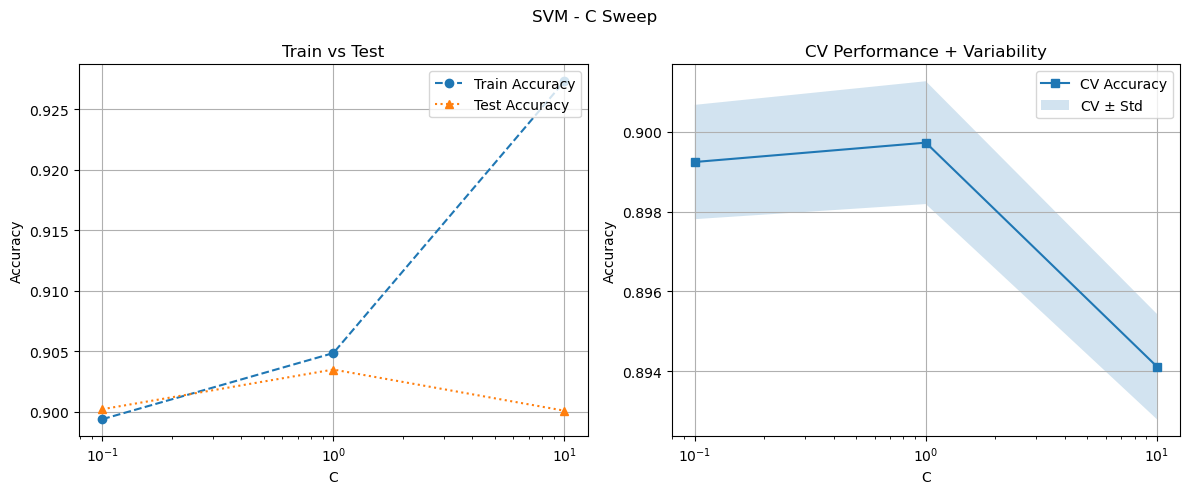

,Train Accuracy,CV Accuracy,CV Std,Test Accuracy
C,,,,
0.1,0.899393,0.899241,0.001433,0.900218
1.0,0.904856,0.899727,0.001540,0.903496
10.0,0.927314,0.894112,0.001321,0.900097


In [32]:
##########################################
##########################################
#
#         SUPPORT VECTOR MACHINES
#
#                C SWEEP
#                  PLOT
#
##########################################
##########################################


##########################################
# Load Results
##########################################

df_svm_c = pd.read_csv("svm_c.csv").sort_values("C")


fig, axes = plt.subplots(1, 2, figsize = (12, 5))


##########################################
# Plot: Train vs Test
##########################################


axes[0].semilogx(
    df_svm_c["C"],
    df_svm_c["Train Accuracy"],
    linestyle = "--",
    marker = "o",
    label = "Train Accuracy"
)


axes[0].semilogx(
    df_svm_c["C"],
    df_svm_c["Test Accuracy"],
    linestyle = ":",
    marker = "^",
    label = "Test Accuracy"
)


axes[0].set_title("Train vs Test")
axes[0].set_xlabel("C")
axes[0].set_ylabel("Accuracy")


axes[0].set_xticks(df_svm_c["C"])


axes[0].legend(loc = "upper right")
axes[0].grid(True)



##########################################
# Plot: CV Performance
##########################################

axes[1].semilogx(
    df_svm_c["C"],
    df_svm_c["CV Accuracy"],
    linestyle = "-",
    marker = "s",
    label = "CV Accuracy"
)


axes[1].fill_between(
    df_svm_c["C"],
    df_svm_c["CV Accuracy"] - df_svm_c["CV Std"],
    df_svm_c["CV Accuracy"] + df_svm_c["CV Std"],
    alpha = 0.2,
    label = "CV $\pm$ Std"
)


axes[1].set_title("CV Performance + Variability")
axes[1].set_xlabel("C")
axes[1].set_ylabel("Accuracy")


axes[1].set_xticks(df_svm_c["C"])

axes[1].legend(loc = "upper right")
axes[1].grid(True)



##########################################
# Final Plot Formatting
##########################################

fig.suptitle("SVM - C Sweep")


plt.tight_layout()
plt.show()


##########################################
# Display Results
##########################################

display(
    df_svm_c
    .set_index("C")
    [
        [
            "Train Accuracy",
            "CV Accuracy",
            "CV Std",
            "Test Accuracy"
        ]
    ]
)
    

### C Sweep Insights

The C parameter controls the trade-off between margin width and classification error.

Higher values improve training accuracy but offer limited improvement on test performance, indicating diminishing returns.

Moderate values provide a stable balance between flexibility and generalization.

### Gamma Sweep

In [33]:
##########################################
##########################################
#
#         SUPPORT VECTOR MACHINES
#
#               GAMMA SWEEP
#               CALCULATION
#
##########################################
##########################################


##########################################
# Hyperparameters
##########################################

gamma_values = [0.01, 0.1, 1]

c_fixed = 1

svm_gamma_rows = []


##########################################
# Model Training Loop
##########################################

for gamma_value in gamma_values:

    pipeline = (
        Pipeline(
            [
                ("preprocess", preprocessor),
                ("model", SVC(
                    C = c_fixed, 
                    kernel = "rbf",
                    gamma = gamma_value
                ))
            ]
        )
    )


    cv_scores = (
        cross_val_score(
            pipeline,
            X_train,
            y_train,
            cv = cv,
            scoring = "accuracy"
        )
    )

    pipeline.fit(X_train, y_train)


    train_accuracy = pipeline.score(X_train, y_train)

    test_accuracy = pipeline.score(X_test, y_test)


    svm_gamma_rows.append(
        {
            "Gamma" : gamma_value,
            "Train Accuracy" : train_accuracy,
            "CV Accuracy" : cv_scores.mean(),
            "CV Std" : cv_scores.std(),
            "Test Accuracy" : test_accuracy
        }
    )


##########################################
# Save Results
##########################################

df_svm_gamma = pd.DataFrame(svm_gamma_rows)


df_svm_gamma.to_csv("svm_gamma.csv", index = False)




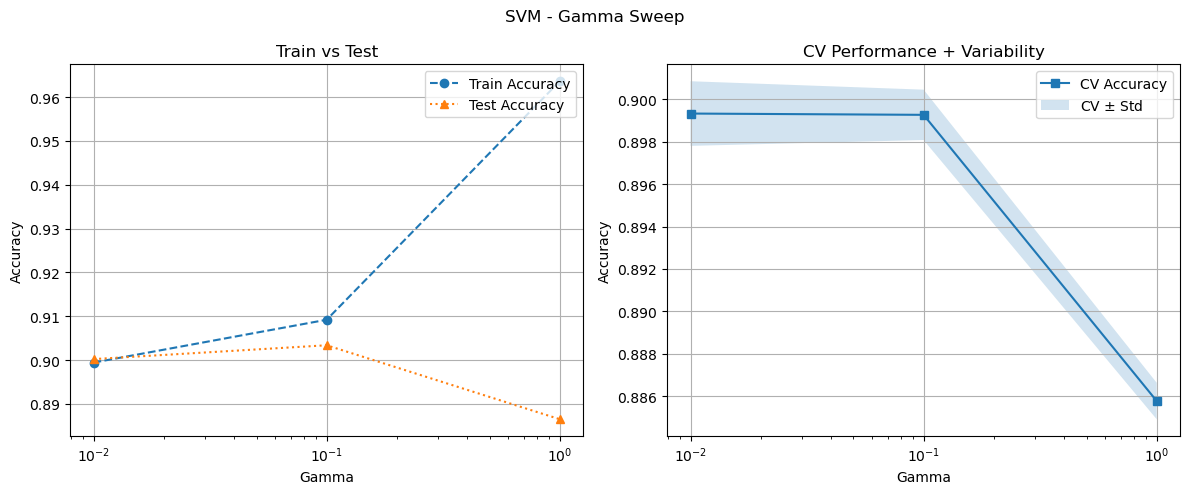

,Train Accuracy,CV Accuracy,CV Std,Test Accuracy
Gamma,,,,
0.01,0.899423,0.899332,0.001525,0.900218
0.10,0.909196,0.899272,0.001189,0.903375
1.00,0.963612,0.885766,0.000861,0.886502


In [34]:
##########################################
##########################################
#
#         SUPPORT VECTOR MACHINES
#
#               GAMMA SWEEP
#                  PLOT
#
##########################################
##########################################


##########################################
# Load Results
##########################################

df_svm_gamma = pd.read_csv("svm_gamma.csv").sort_values("Gamma")


fig, axes = plt.subplots(1, 2, figsize = (12, 5))


##########################################
# Plot: Train vs Test
##########################################

axes[0].semilogx(
    df_svm_gamma["Gamma"],
    df_svm_gamma["Train Accuracy"],
    linestyle = "--",
    marker = "o",
    label = "Train Accuracy"
)


axes[0].semilogx(
    df_svm_gamma["Gamma"],
    df_svm_gamma["Test Accuracy"],
    linestyle = ":",
    marker = "^",
    label = "Test Accuracy"
)

axes[0].set_title("Train vs Test")
axes[0].set_xlabel("Gamma")
axes[0].set_ylabel("Accuracy")

axes[0].set_xticks(df_svm_gamma["Gamma"])

axes[0].legend(loc = "upper right")
axes[0].grid(True)


##########################################
# Plot: CV Performance
##########################################

axes[1].semilogx(
    df_svm_gamma["Gamma"],
    df_svm_gamma["CV Accuracy"],
    linestyle = "-",
    marker = "s",
    label = "CV Accuracy"
)

axes[1].fill_between(
    df_svm_gamma["Gamma"],
    df_svm_gamma["CV Accuracy"] - df_svm_gamma["CV Std"],
    df_svm_gamma["CV Accuracy"] + df_svm_gamma["CV Std"],
    alpha = 0.2,
    label = "CV $\pm$ Std"
)


axes[1].set_title("CV Performance + Variability")
axes[1].set_xlabel("Gamma")
axes[1].set_ylabel("Accuracy")


axes[1].set_xticks(df_svm_gamma["Gamma"])

axes[1].legend(loc = "upper right")
axes[1].grid(True)


##########################################
# Final Plot Formatting
##########################################

fig.suptitle("SVM - Gamma Sweep")


plt.tight_layout()
plt.show()


##########################################
# Display Results
##########################################


display(
    df_svm_gamma
    .set_index("Gamma")
    [
        [
            "Train Accuracy",
            "CV Accuracy",
            "CV Std",
            "Test Accuracy"
        ]
    ]
)



### Gamma Sweep Insights

Gamma controls the influence of individual training points in the decision boundary.

Higher values increase model complexity and risk overfitting, while lower values produce smoother boundaries.

Moderate gamma values provide the most consistent performance. 

### Heatmap

In [35]:
##########################################
##########################################
#
#         SUPPORT VECTOR MACHINES
#
#           HYPERPARAMETER HEATMAP
#               CALCULATION
#
##########################################
##########################################


##########################################
# Hyperparameters
##########################################

c_values = [0.1, 1, 10]

gamma_values = [0.01, 0.1, 1]


svm_heat_rows = []



##########################################
# Model Training Loop
##########################################

for c_value in c_values:
    for gamma_value in gamma_values:


        pipeline = (
            Pipeline(
                [
                    ("preprocess", preprocessor),
                    ("model", SVC(
                        C = c_value, 
                        kernel = "rbf", 
                        gamma = gamma_value
                    ))
                ]
            )
        )


        cv_scores = (
            cross_val_score(
                pipeline,
                X_train,
                y_train,
                cv = cv,
                scoring = "accuracy"
            )
        )
    
        pipeline.fit(X_train, y_train)
    
    
        train_accuracy = pipeline.score(X_train, y_train)
    
        test_accuracy = pipeline.score(X_test, y_test)
    
    
        svm_heat_rows.append(
            {
                "C" : c_value,
                "Gamma" : gamma_value,
                "Train Accuracy" : train_accuracy,
                "CV Accuracy" : cv_scores.mean(),
                "CV Std" : cv_scores.std(),
                "Test Accuracy" : test_accuracy
            }
        )


##########################################
# Save Results
##########################################

df_svm_heat = pd.DataFrame(svm_heat_rows)


df_svm_heat.to_csv("svm_heat.csv", index = False)




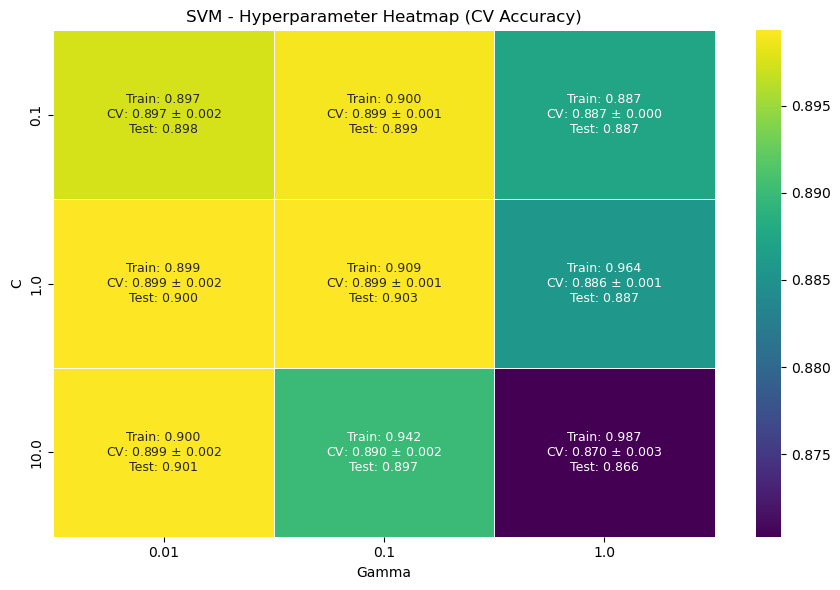

In [36]:
##########################################
##########################################
#
#         SUPPORT VECTOR MACHINES
#
#           HYPERPARAMETER HEATMAP
#                 PLOT
#
##########################################
##########################################


##########################################
# Load Results
##########################################

df_svm_heat = pd.read_csv("svm_heat.csv")


##########################################
# Create Annotations
##########################################


df_svm_heat["label"] = df_svm_heat.apply(
    lambda row: (
        f"Train: {row['Train Accuracy']:.3f}\n"
        f"CV: {row['CV Accuracy']:.3f} $\pm$ {row['CV Std']:.3f}\n"
        f"Test: {row['Test Accuracy']:.3f}"
    ), 
    axis = 1
)


##########################################
# Pivot Tables
##########################################

c_order = sorted(df_svm_heat["C"].unique())

gamma_order = sorted(df_svm_heat["Gamma"].unique())


svm_mean_table = df_svm_heat.pivot(
    index = "C",
    columns = "Gamma",
    values = "CV Accuracy"
).reindex(index = c_order, columns = gamma_order)


svm_label_table = df_svm_heat.pivot(
    index = "C",
    columns = "Gamma", 
    values = "label"
).reindex(index = c_order, columns = gamma_order)



##########################################
# Plot: Heatmap
##########################################


plt.figure(figsize = (9, 6))

sns.heatmap(
    svm_mean_table,
    annot = svm_label_table,
    fmt = "",
    cmap = "viridis",
    linewidths = 0.5,
    linecolor = "white",
    annot_kws = {"fontsize" : 9}
)

plt.title("SVM - Hyperparameter Heatmap (CV Accuracy)")
plt.xlabel("Gamma")
plt.ylabel("C")

plt.tight_layout()
plt.show()




### Heatmap Insights

The heatmap highlights the interaction between C and gamma.

Results show that combinations of moderate regularization and controlled kernel complexity yield the best performance, while extreme values lead to instability.

SVM provides strong performance but at a higher computational cost compared to simpler models.

### Support Vector Machines Summary

SVM is a powerful non-linear model capable of capturing complex patterns.

However, it requires careful tuning and is computationally expensive compared to other models. 

The final selected model uses C = 1 and gamma = 0.1.



## Best Model Comparison

In [37]:
##########################################
##########################################
#
#          BEST MODEL COMPARISON
#               CALCULATION
#
##########################################
##########################################



best_models = {

    "Dummy (Baseline)" : DummyClassifier(strategy = "most_frequent"),
    
    "Logistic Regression" : LogisticRegression(
        C = 0.1, 
        max_iter = 1000
    ),

    "Decision Tree" : DecisionTreeClassifier(
        max_depth = 5, 
        min_samples_leaf = 20,
        random_state = 42
    ),

    "KNN" : KNeighborsClassifier(
        n_neighbors = 21
    ),

    "SVM" : SVC(
        C = 1,
        gamma = 0.1,
        kernel = "rbf"
    )
}


best_rows = []



##########################################
# Model Training Loop
##########################################


for name, model in best_models.items():


    pipeline = (
        Pipeline(
            [
                ("preprocess", preprocessor),
                ("model", model)
            ]
        )
    )

    cv_scores = (
        cross_val_score(
            pipeline,
            X_train,
            y_train,
            cv = cv,
            scoring = "accuracy"
        )
    )


    start = time.time()

    pipeline.fit(X_train, y_train)

    train_time = time.time() - start


    train_accuracy = pipeline.score(X_train, y_train)

    test_accuracy = pipeline.score(X_test, y_test)


    best_rows.append(
        {
            "Model" : name,
            "Train Time" : train_time,
            "Train Accuracy" : train_accuracy,
            "CV Accuracy" : cv_scores.mean(),
            "CV Std" : cv_scores.std(),
            "Test Accuracy" : test_accuracy
        }
    )



##########################################
# Save Results
##########################################

df_best = pd.DataFrame(best_rows)



df_best.to_csv("best.csv", index = False)



In [38]:
##########################################
##########################################
#
#          BEST MODEL COMPARISON
#                RESULTS
#
##########################################
##########################################



##########################################
# Load Results
##########################################
    
df_best = pd.read_csv("best.csv")



##########################################
# Display Results
##########################################

display(
    df_best
    .set_index("Model")
    [
        [
            "Train Time",
            "Train Accuracy",
            "CV Accuracy",
            "CV Std",
            "Test Accuracy"
        ]
    ]
)




,Train Time,Train Accuracy,CV Accuracy,CV Std,Test Accuracy
Model,,,,,
Dummy (Baseline),0.059531,0.887344,0.887344,0.000074,0.887351
Logistic Regression,0.251970,0.900273,0.899697,0.002061,0.901797
Decision Tree,0.112843,0.902762,0.899575,0.002474,0.902161
KNN,0.064465,0.902853,0.898665,0.000805,0.901068
SVM,73.839939,0.909196,0.899272,0.001189,0.903375


## Insights

After hyperparameter tuning, the best configurations from each model were compared.

Improvements over default models are modest, suggesting that model choice has limited impact given the available features alone. 

Logistic Regression and Decision Trees provide strong performance with lower computational cost, while SVM achieves similar accuracy with higher cost.

Final model selection balances performance, interpretability, and efficiency. 

## Precision-Recall Analysis

### Introduction

Precision-recall analysis evaluates model performance across different classification thresholds.

While accuracy provides a single summary metric, precision and recall highlight the trade-off between false positives and false negatives, which is important for decision-making in a marketing context.

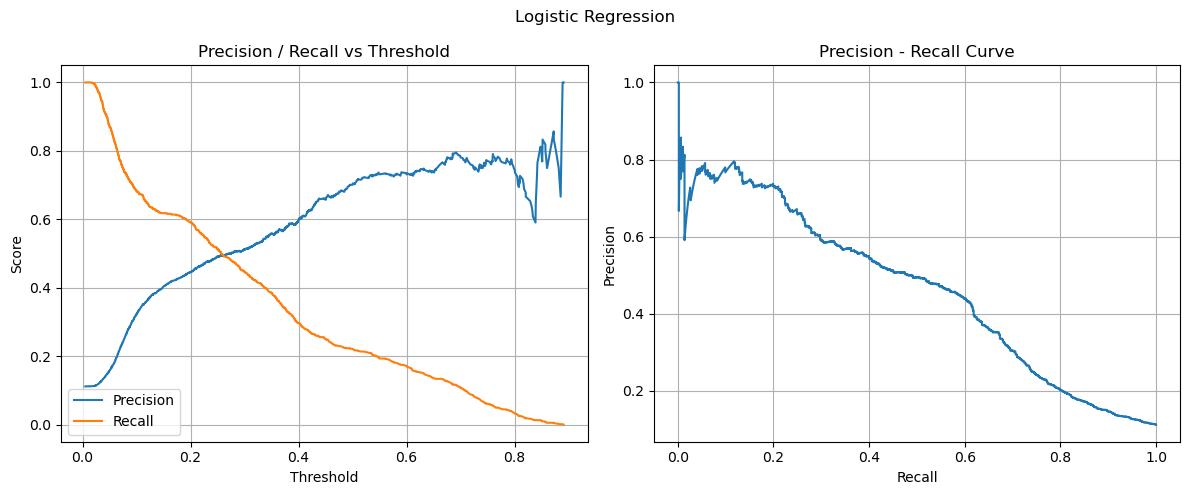

In [39]:
##########################################
##########################################
#
#          PRECISION-RECALL ANALYSIS
#            LOGISTIC REGRESSION
#
##########################################
##########################################


model = LogisticRegression(
    C = 0.1,
    max_iter = 1000
)


pipeline = (
    Pipeline(
        [
            ("preprocess", preprocessor),
            ("model", model)
        ]
    )
)


##########################################
# Fit Model and Generate Probabilities
##########################################


pipeline.fit(X_train, y_train)


y_probs = pipeline.predict_proba(X_test)[:, 1]


precision, recall, thresholds = precision_recall_curve(y_test, y_probs)



##########################################
# Plot: Precision-Recall Analysis
##########################################


fig, axes = plt.subplots(1, 2, figsize = (12, 5))


axes[0].plot(
    thresholds,
    precision[:-1],
    linestyle = "-",
    label = "Precision"
)


axes[0].plot(
    thresholds,
    recall[:-1],
    linestyle = "-",
    label = "Recall"
)


axes[0].set_title("Precision / Recall vs Threshold")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")

axes[0].legend()
axes[0].grid(True)



axes[1].plot(
    recall,
    precision,
    linestyle = "-"
)


axes[1].set_title("Precision - Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

axes[1].grid(True)



fig.suptitle("Logistic Regression")

plt.tight_layout()
plt.show()






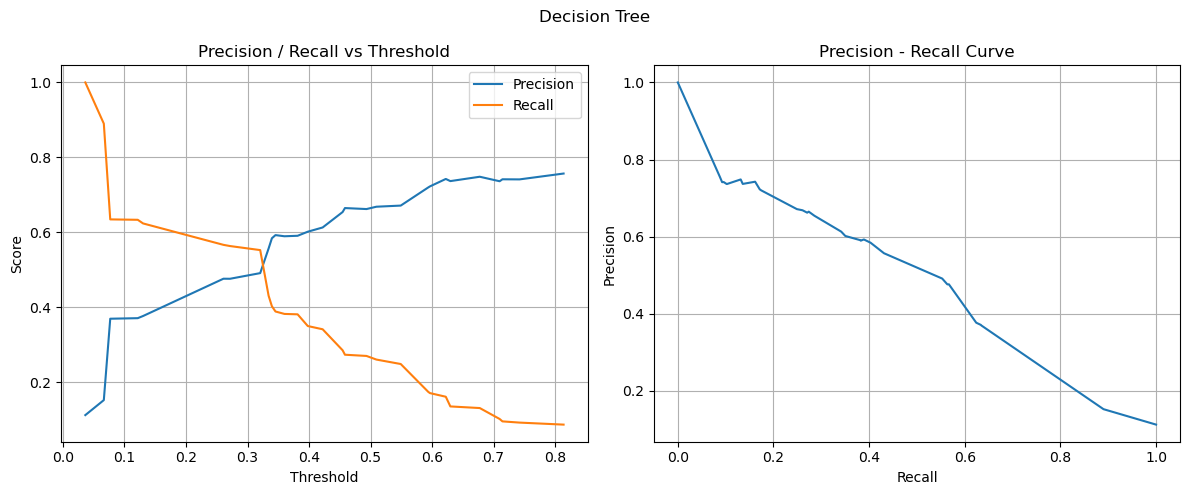

In [40]:
##########################################
##########################################
#
#          PRECISION-RECALL ANALYSIS
#            DECISION TREE
#
##########################################
##########################################


model = DecisionTreeClassifier(
    max_depth = 5,
    min_samples_leaf = 20,
    random_state = 42
)


pipeline = (
    Pipeline(
        [
            ("preprocess", preprocessor),
            ("model", model)
        ]
    )
)


##########################################
# Fit Model and Generate Probabilities
##########################################


pipeline.fit(X_train, y_train)


y_probs = pipeline.predict_proba(X_test)[:, 1]


precision, recall, thresholds = precision_recall_curve(y_test, y_probs)



##########################################
# Plot: Precision-Recall Analysis
##########################################


fig, axes = plt.subplots(1, 2, figsize = (12, 5))


axes[0].plot(
    thresholds,
    precision[:-1],
    linestyle = "-",
    label = "Precision"
)


axes[0].plot(
    thresholds,
    recall[:-1],
    linestyle = "-",
    label = "Recall"
)


axes[0].set_title("Precision / Recall vs Threshold")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")

axes[0].legend()
axes[0].grid(True)



axes[1].plot(
    recall,
    precision,
    linestyle = "-"
)


axes[1].set_title("Precision - Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

axes[1].grid(True)



fig.suptitle("Decision Tree")

plt.tight_layout()
plt.show()






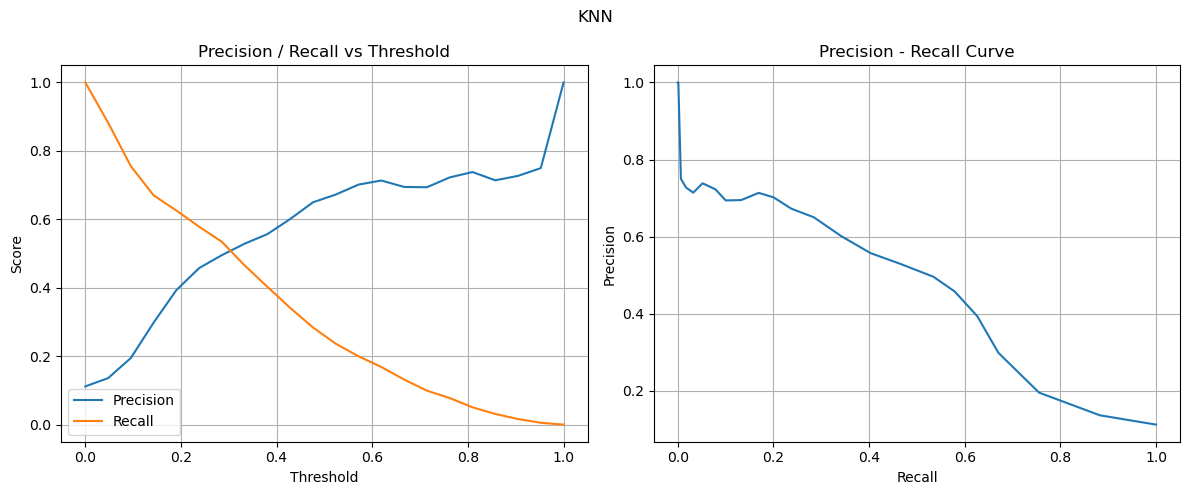

In [41]:
##########################################
##########################################
#
#          PRECISION-RECALL ANALYSIS
#            K NEAREST NEIGHBORS
#
##########################################
##########################################


model = KNeighborsClassifier(
    n_neighbors = 21
)


pipeline = (
    Pipeline(
        [
            ("preprocess", preprocessor),
            ("model", model)
        ]
    )
)


##########################################
# Fit Model and Generate Probabilities
##########################################


pipeline.fit(X_train, y_train)


y_probs = pipeline.predict_proba(X_test)[:, 1]


precision, recall, thresholds = precision_recall_curve(y_test, y_probs)



##########################################
# Plot: Precision-Recall Analysis
##########################################


fig, axes = plt.subplots(1, 2, figsize = (12, 5))


axes[0].plot(
    thresholds,
    precision[:-1],
    linestyle = "-",
    label = "Precision"
)


axes[0].plot(
    thresholds,
    recall[:-1],
    linestyle = "-",
    label = "Recall"
)


axes[0].set_title("Precision / Recall vs Threshold")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")

axes[0].legend()
axes[0].grid(True)



axes[1].plot(
    recall,
    precision,
    linestyle = "-"
)


axes[1].set_title("Precision - Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

axes[1].grid(True)



fig.suptitle("KNN")

plt.tight_layout()
plt.show()






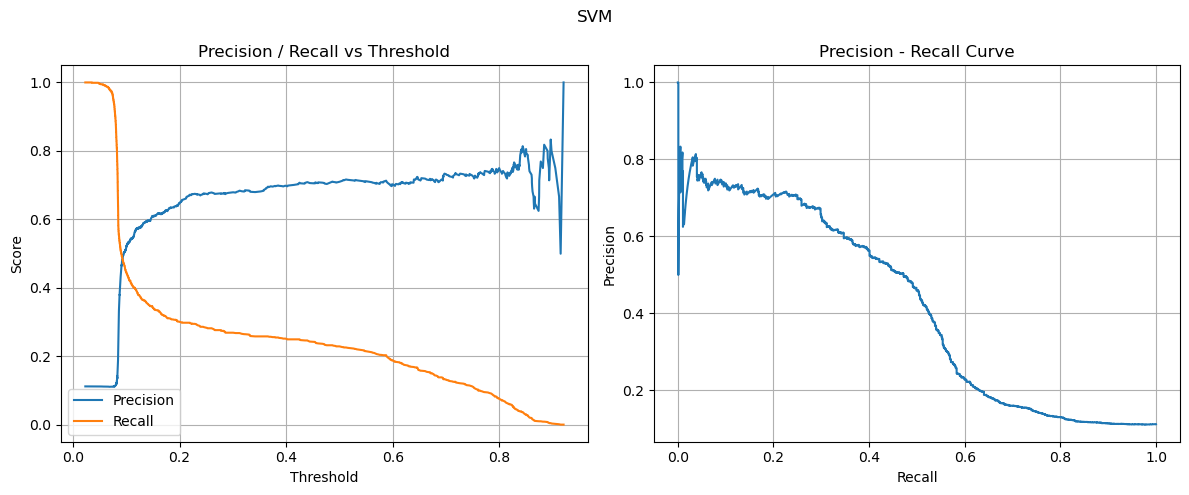

In [42]:
##########################################
##########################################
#
#          PRECISION-RECALL ANALYSIS
#           SUPPORT VECTOR MACHINES
#
##########################################
##########################################


model = SVC(
    C = 1,
    gamma = 0.1,
    kernel = "rbf",
    probability = True
)


pipeline = (
    Pipeline(
        [
            ("preprocess", preprocessor),
            ("model", model)
        ]
    )
)


##########################################
# Fit Model and Generate Probabilities
##########################################


pipeline.fit(X_train, y_train)


y_probs = pipeline.predict_proba(X_test)[:, 1]


precision, recall, thresholds = precision_recall_curve(y_test, y_probs)



##########################################
# Plot: Precision-Recall Analysis
##########################################


fig, axes = plt.subplots(1, 2, figsize = (12, 5))


axes[0].plot(
    thresholds,
    precision[:-1],
    linestyle = "-",
    label = "Precision"
)


axes[0].plot(
    thresholds,
    recall[:-1],
    linestyle = "-",
    label = "Recall"
)


axes[0].set_title("Precision / Recall vs Threshold")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")

axes[0].legend()
axes[0].grid(True)



axes[1].plot(
    recall,
    precision,
    linestyle = "-"
)


axes[1].set_title("Precision - Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

axes[1].grid(True)



fig.suptitle("SVM")

plt.tight_layout()
plt.show()






### Insights

The precision-recall curves show generally consistent behavior across most model families, with similar trade-offs between precision and recall.

Precision and recall typically intersect near a threshold of approximately 0.3, with an observable elbow around recall = 0.6 and precision = 0.4.

However, the SVM model deviates slightly from this pattern, with an earlier intersection point and a less pronounced elbow. This difference is due to the way SVM probabilities are estimated, resulting in a shifted threshold behavior.

Overall, threshold selection remains a key factor in controlling performance trade-offs across models. 


### Duration Investigation

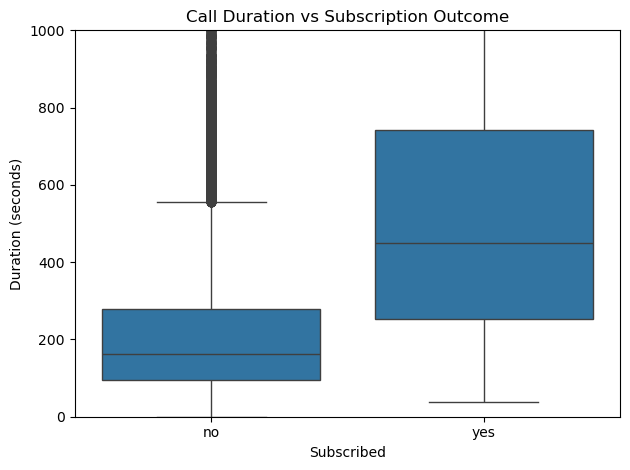

In [43]:
##########################################
# Plot: Call Duration vs Subscription Outcome
##########################################


df_duration = pd.read_csv("data/bank-additional-full.csv", sep = ";")


sns.boxplot(
    data = df_duration,
    x = "y",
    y = "duration"
)


plt.title("Call Duration vs Subscription Outcome")
plt.xlabel("Subscribed")
plt.ylabel("Duration (seconds)")

plt.ylim(0, 1000)


plt.tight_layout()
plt.show()




## FINAL SUMMARY

The models demonstrate that while predictive signal exists, improvements through model complexity are limited.

Prior campaign outcomes, particularly previous success, provide meaningful signal, while other features contribute less significantly to predictive performance. 

Logistic Regression offers a strong balance of performance and simplicity, making it a practical choice for deployment.

Call duration is highly predictive but represents data leakage and cannot be used in a real-world setting. 

These findings emphasize the importance of feature quality over model complexity in this problem. 


![helllo](images/knn.png)